# 🚢 MLflow Lab — Titanic Survival Prediction

**Dataset:** Titanic (binary classification — `Survived`: 0 or 1)  
**Models:** Logistic Regression (baseline) → Random Forest → LightGBM + Hyperopt  
**MLflow Extras:** tags, custom artifacts (confusion matrix, feature importance), multi-metric logging

### Pipeline Flow
```
Load Data → Preprocess → Baseline LR → Random Forest → LightGBM+Hyperopt → Register → Serve
```

## 📦 Step 0 — Install & Import Dependencies

In [3]:
# Uncomment and run once if packages are missing
# !pip install mlflow scikit-learn lightgbm hyperopt seaborn matplotlib cloudpickle

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# MLflow
import mlflow
import mlflow.sklearn
import mlflow.lightgbm
import mlflow.pyfunc
from mlflow.models.signature import infer_signature
from mlflow.tracking import MlflowClient

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, accuracy_score, f1_score,
    confusion_matrix, classification_report
)
from sklearn.preprocessing import StandardScaler

# LightGBM + Hyperopt
import lightgbm as lgb
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK
from hyperopt.pyll import scope

import cloudpickle, time, os

print(f"MLflow version : {mlflow.__version__}")
print(f"LightGBM version: {lgb.__version__}")
print("✅ All imports successful")

MLflow version : 3.11.1
LightGBM version: 4.6.0
✅ All imports successful


## 📊 Step 1 — Load Titanic Dataset

Loaded directly from seaborn — no CSV download needed.

In [6]:
titanic = sns.load_dataset('titanic')
print(f"Shape: {titanic.shape}")
print(f"Columns: {titanic.columns.tolist()}")
titanic.head()

Shape: (891, 15)
Columns: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [7]:
print("Missing values:\n", titanic.isnull().sum())

Missing values:
 survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


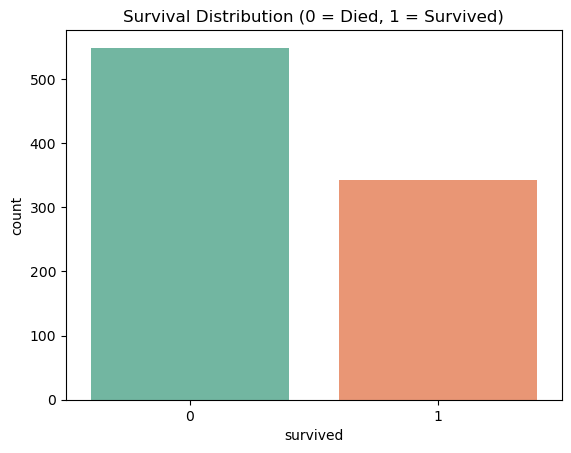

Survival rate: 38.38%


In [8]:
sns.countplot(x='survived', data=titanic, palette='Set2')
plt.title('Survival Distribution (0 = Died, 1 = Survived)')
plt.show()
print(f"Survival rate: {titanic['survived'].mean():.2%}")

## 🔧 Step 2 — Preprocessing

- Drop leaky / low-value columns
- Fill missing `age` (median), `embarked` (mode)
- Encode sex + embarked
- Engineer `family_size`, `is_alone`
- Scale for Logistic Regression

In [10]:
def preprocess_titanic(df):
    df = df.copy()

    # Drop redundant/leaky columns
    drop_cols = ['alive', 'who', 'adult_male', 'deck', 'embark_town', 'class']
    df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)

    # Fill missing
    df['age'].fillna(df['age'].median(), inplace=True)
    df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)

    # Encode sex
    df['sex'] = (df['sex'] == 'male').astype(int)

    # One-hot encode embarked
    embarked_dummies = pd.get_dummies(df['embarked'], prefix='embarked', drop_first=True)
    df = pd.concat([df.drop('embarked', axis=1), embarked_dummies], axis=1)

    # Feature engineering
    df['family_size'] = df['sibsp'] + df['parch']
    df['is_alone']    = (df['family_size'] == 0).astype(int)

    y = df['survived']
    X = df.drop('survived', axis=1).select_dtypes(include=[np.number])
    return X, y


X, y = preprocess_titanic(titanic)
print(f"Features ({X.shape[1]}): {X.columns.tolist()}")
X.head()

Features (8): ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'family_size', 'is_alone']


,pclass,sex,age,sibsp,parch,fare,family_size,is_alone
0,3,1,22.0,1,0,7.2500,1,0
1,1,0,38.0,1,0,71.2833,1,0
2,3,0,26.0,0,0,7.9250,0,1
3,1,0,35.0,1,0,53.1000,1,0
4,3,1,35.0,0,0,8.0500,0,1


In [11]:
# 60 / 20 / 20 stratified split
X_train, X_rem, y_train, y_rem = train_test_split(
    X, y, train_size=0.6, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_rem, y_rem, test_size=0.5, random_state=42, stratify=y_rem
)

print(f"Train: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}")

# Scale (fit on train only)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_val_scaled   = pd.DataFrame(scaler.transform(X_val),       columns=X_val.columns)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),      columns=X_test.columns)

print("✅ Split and scaling done")

Train: 534 | Val: 178 | Test: 179
✅ Split and scaling done


---
### ✅ Batch 1 Complete — Data loaded, cleaned, split, scaled
**Next → Batch 2: MLflow experiment setup + Logistic Regression baseline**

---
## 🧪 Batch 2 — MLflow Setup + Logistic Regression Baseline

### What we do here:
- Set up a named **MLflow experiment** (`titanic_survival`)
- Log **tags** (author, dataset, model type) — great for filtering in the UI
- Log **multiple metrics** (AUC, Accuracy, F1)
- Log a **confusion matrix** as a PNG artifact
- Log the trained model with a **signature**

> 💡 **What is a Run?** Every `mlflow.start_run()` block = one experiment run.  
> MLflow records params, metrics, tags, and artifacts under that run ID.

## 🗂️ Step 3 — Create MLflow Experiment

In [15]:
# Name our experiment — MLflow creates it if it doesn't exist
EXPERIMENT_NAME = "titanic_survival"
mlflow.set_experiment(EXPERIMENT_NAME)

# Point to local tracking server (default: ./mlruns folder)
# If you run `mlflow ui` in terminal, you can view this at http://127.0.0.1:5000
print(f"Active experiment: {mlflow.get_experiment_by_name(EXPERIMENT_NAME).name}")
print(f"Experiment ID    : {mlflow.get_experiment_by_name(EXPERIMENT_NAME).experiment_id}")

Active experiment: titanic_survival
Experiment ID    : 1


## 🔧 Step 4 — Helper: log_confusion_matrix()

This helper generates a confusion matrix plot and **logs it as an MLflow artifact** — 
meaning the PNG is saved and attached to the run, visible in the MLflow UI.

In [17]:
def log_confusion_matrix(y_true, y_pred, run_name):
    """
    Plots a confusion matrix and logs it as a PNG artifact to the active MLflow run.
    """
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Died', 'Survived'],
        yticklabels=['Died', 'Survived'],
        ax=ax
    )
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'Confusion Matrix — {run_name}')
    plt.tight_layout()

    # Save temporarily, log to MLflow, then clean up
    artifact_path = f"confusion_matrix_{run_name}.png"
    fig.savefig(artifact_path)
    mlflow.log_artifact(artifact_path)   # <-- this uploads the PNG to the run
    plt.show()
    os.remove(artifact_path)


print("✅ Helper function defined")

✅ Helper function defined


## 🤖 Step 5 — Baseline: Logistic Regression

**Why start here?**  
Logistic Regression is fast, interpretable, and gives a solid baseline AUC.  
Everything we log here will be the benchmark for RF and LightGBM.

**MLflow concepts used:**
| Code | What it does |
|---|---|
| `mlflow.set_tag()` | Labels the run (author, dataset, etc.) |
| `mlflow.log_param()` | Records a hyperparameter |
| `mlflow.log_metric()` | Records a numeric score |
| `mlflow.log_artifact()` | Uploads a file (plot, CSV, etc.) to the run |
| `mlflow.sklearn.log_model()` | Saves the trained model with schema signature |

Logistic Regression Results
  AUC      : 0.8390
  Accuracy : 0.8212
  F1 Score : 0.7460

Classification Report:
              precision    recall  f1-score   support

        Died       0.82      0.91      0.86       110
    Survived       0.82      0.68      0.75        69

    accuracy                           0.82       179
   macro avg       0.82      0.80      0.80       179
weighted avg       0.82      0.82      0.82       179



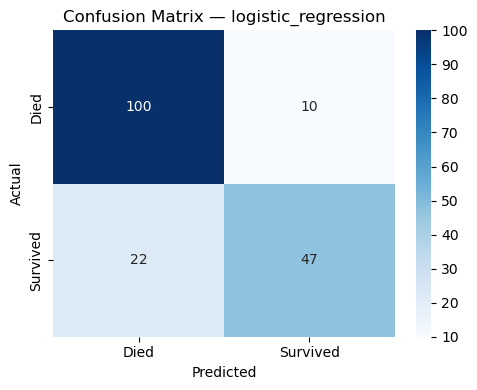

2026/04/07 20:34:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/07 20:34:28 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



✅ Run logged — ID: 8aab5dab238049d7a9526ca165e4ea02


In [19]:
with mlflow.start_run(run_name='logistic_regression_baseline'):

    # ── Tags: label this run for easy filtering in the UI ──────────────────
    mlflow.set_tag('author',     'Ibrahim')        # your name
    mlflow.set_tag('dataset',    'titanic')
    mlflow.set_tag('model_type', 'logistic_regression')
    mlflow.set_tag('split',      '60-20-20')

    # ── Hyperparameters ────────────────────────────────────────────────────
    C          = 1.0
    max_iter   = 1000
    solver     = 'lbfgs'

    mlflow.log_param('C',        C)
    mlflow.log_param('max_iter', max_iter)
    mlflow.log_param('solver',   solver)

    # ── Train ──────────────────────────────────────────────────────────────
    lr_model = LogisticRegression(C=C, max_iter=max_iter, solver=solver, random_state=42)
    lr_model.fit(X_train_scaled, y_train)

    # ── Evaluate on TEST set ───────────────────────────────────────────────
    y_pred_proba = lr_model.predict_proba(X_test_scaled)[:, 1]
    y_pred       = lr_model.predict(X_test_scaled)

    auc      = roc_auc_score(y_test, y_pred_proba)
    accuracy = accuracy_score(y_test, y_pred)
    f1       = f1_score(y_test, y_pred)

    # ── Log multiple metrics ───────────────────────────────────────────────
    mlflow.log_metric('test_auc',      auc)
    mlflow.log_metric('test_accuracy', accuracy)
    mlflow.log_metric('test_f1',       f1)

    print(f"Logistic Regression Results")
    print(f"  AUC      : {auc:.4f}")
    print(f"  Accuracy : {accuracy:.4f}")
    print(f"  F1 Score : {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Died', 'Survived']))

    # ── Log confusion matrix as artifact ───────────────────────────────────
    log_confusion_matrix(y_test, y_pred, 'logistic_regression')

    # ── Log model with signature ───────────────────────────────────────────
    signature = infer_signature(X_train_scaled, lr_model.predict_proba(X_train_scaled)[:, 1])
    mlflow.sklearn.log_model(
        lr_model,
        artifact_path='logistic_regression_model',
        signature=signature
    )

    # Save run_id so we can reference it later
    lr_run_id = mlflow.active_run().info.run_id
    print(f"\n✅ Run logged — ID: {lr_run_id}")

## 🔍 Step 6 — Inspect the Run via MlflowClient

The `MlflowClient` lets you query runs programmatically — 
same info you'd see in the MLflow UI under the `titanic_survival` experiment.

In [21]:
client = MlflowClient()

# Fetch the run we just logged
lr_run = client.get_run(lr_run_id)

print("=== Run Info ===")
print(f"Run Name : {lr_run.data.tags.get('mlflow.runName')}")
print(f"Run ID   : {lr_run.info.run_id}")
print(f"Status   : {lr_run.info.status}")

print("\n=== Parameters ===")
for k, v in lr_run.data.params.items():
    print(f"  {k}: {v}")

print("\n=== Metrics ===")
for k, v in lr_run.data.metrics.items():
    print(f"  {k}: {v:.4f}")

print("\n=== Tags ===")
for k, v in lr_run.data.tags.items():
    if not k.startswith('mlflow.'):
        print(f"  {k}: {v}")

=== Run Info ===
Run Name : logistic_regression_baseline
Run ID   : 8aab5dab238049d7a9526ca165e4ea02
Status   : FINISHED

=== Parameters ===
  C: 1.0
  max_iter: 1000
  solver: lbfgs

=== Metrics ===
  test_auc: 0.8390
  test_accuracy: 0.8212
  test_f1: 0.7460

=== Tags ===
  author: Ibrahim
  dataset: titanic
  model_type: logistic_regression
  split: 60-20-20


## 💻 Step 7 — Launch MLflow UI

Run this in your **terminal** (not inside the notebook) to open the UI:
```bash
mlflow ui
# Then open: http://127.0.0.1:5000
# Navigate to experiment: titanic_survival
# You'll see the logistic_regression_baseline run with all metrics, tags, and the confusion matrix PNG
```

> Or run the cell below to launch from the notebook (blocks kernel while running):

In [23]:
# Uncomment to launch UI from notebook (will block — use terminal instead)
# !mlflow ui --port 5000

---
### ✅ Batch 2 Complete!

**What was logged for Logistic Regression:**
- 🏷️ Tags: `author`, `dataset`, `model_type`, `split`
- ⚙️ Params: `C`, `max_iter`, `solver`
- 📊 Metrics: `test_auc`, `test_accuracy`, `test_f1`
- 🖼️ Artifact: `confusion_matrix_logistic_regression.png`
- 🤖 Model: saved with input/output signature

**Next → Batch 3: Random Forest run with feature importance artifact**

---
## 🌲 Batch 3 — Random Forest + Feature Importance Artifact

### What's new vs Logistic Regression:
- New helper `log_feature_importance()` — ranked bar chart saved as artifact
- Log **both val and test metrics** — spot overfitting in the UI
- `mlflow.log_dict()` — log feature importances as a JSON artifact too
- `mlflow.search_runs()` — side-by-side comparison of LR vs RF at the end

> 💡 **What is an artifact?** Any file attached to a run — plots, CSVs, JSONs.  
> Visible in the MLflow UI under the run's **Artifacts** tab.

## 🔧 Step 8 — Helper: log_feature_importance()

In [27]:
def log_feature_importance(model, feature_names, run_name, top_n=10):
    """
    Plots top-N feature importances and logs PNG + JSON artifacts to the active MLflow run.
    """
    importances = pd.Series(
        model.feature_importances_,
        index=feature_names
    ).sort_values(ascending=False).head(top_n)

    # Plot
    fig, ax = plt.subplots(figsize=(8, 5))
    importances.sort_values().plot(kind='barh', color='steelblue', ax=ax)
    ax.set_title(f'Top {top_n} Feature Importances — {run_name}')
    ax.set_xlabel('Importance Score')
    plt.tight_layout()

    # Log PNG artifact
    png_path = f"feature_importance_{run_name}.png"
    fig.savefig(png_path)
    mlflow.log_artifact(png_path)
    plt.show()
    os.remove(png_path)

    # Log raw importances as JSON artifact
    mlflow.log_dict(importances.to_dict(), artifact_file='feature_importances.json')

    return importances


print('✅ Feature importance helper defined')

✅ Feature importance helper defined


## 🌲 Step 9 — Random Forest Run

Random Forest Results
  Val  AUC : 0.8668
  Test AUC : 0.8203
  Test Acc : 0.7877
  Test F1  : 0.7031

              precision    recall  f1-score   support

        Died       0.80      0.87      0.83       110
    Survived       0.76      0.65      0.70        69

    accuracy                           0.79       179
   macro avg       0.78      0.76      0.77       179
weighted avg       0.79      0.79      0.78       179



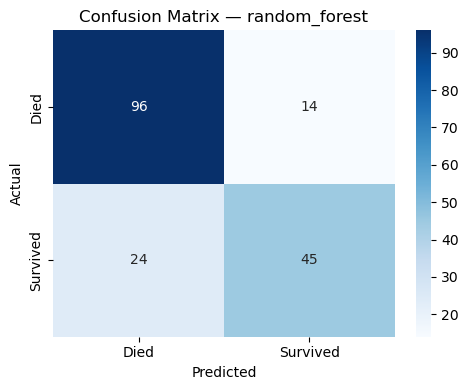

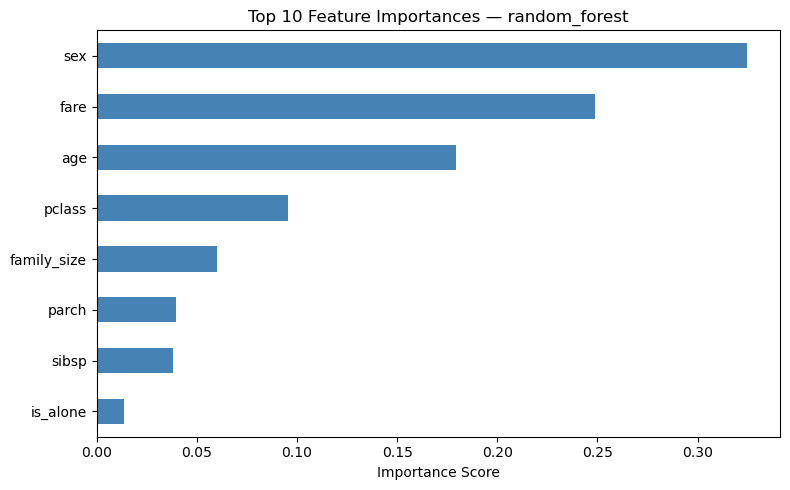

2026/04/07 20:34:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/07 20:34:40 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



✅ RF run logged — ID: 36eb063734ed458b81e79b694859e3a6


In [29]:
with mlflow.start_run(run_name='random_forest'):

    # Tags
    mlflow.set_tag('author',     'Ibrahim')
    mlflow.set_tag('dataset',    'titanic')
    mlflow.set_tag('model_type', 'random_forest')
    mlflow.set_tag('split',      '60-20-20')
    mlflow.set_tag('note',       'untuned baseline RF — compare with LightGBM sweep')

    # Hyperparameters
    n_estimators      = 100
    max_depth         = 8
    min_samples_split = 4
    mlflow.log_param('n_estimators',      n_estimators)
    mlflow.log_param('max_depth',         max_depth)
    mlflow.log_param('min_samples_split', min_samples_split)
    mlflow.log_param('features_used',     X_train.shape[1])

    # Train (RF doesn't need scaled data)
    rf_model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        random_state=42,
        n_jobs=-1
    )
    rf_model.fit(X_train, y_train)

    # Val metrics
    y_val_proba = rf_model.predict_proba(X_val)[:, 1]
    y_val_pred  = rf_model.predict(X_val)
    mlflow.log_metric('val_auc',      roc_auc_score(y_val, y_val_proba))
    mlflow.log_metric('val_accuracy', accuracy_score(y_val, y_val_pred))
    mlflow.log_metric('val_f1',       f1_score(y_val, y_val_pred))

    # Test metrics
    y_test_proba  = rf_model.predict_proba(X_test)[:, 1]
    y_test_pred   = rf_model.predict(X_test)
    test_auc      = roc_auc_score(y_test, y_test_proba)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_f1       = f1_score(y_test, y_test_pred)
    mlflow.log_metric('test_auc',      test_auc)
    mlflow.log_metric('test_accuracy', test_accuracy)
    mlflow.log_metric('test_f1',       test_f1)

    print('Random Forest Results')
    print(f'  Val  AUC : {roc_auc_score(y_val, y_val_proba):.4f}')
    print(f'  Test AUC : {test_auc:.4f}')
    print(f'  Test Acc : {test_accuracy:.4f}')
    print(f'  Test F1  : {test_f1:.4f}')
    print()
    print(classification_report(y_test, y_test_pred, target_names=['Died', 'Survived']))

    # Artifacts
    log_confusion_matrix(y_test, y_test_pred, 'random_forest')
    log_feature_importance(rf_model, X_train.columns.tolist(), 'random_forest', top_n=10)

    # Log model
    signature = infer_signature(X_train, rf_model.predict_proba(X_train)[:, 1])
    mlflow.sklearn.log_model(rf_model, artifact_path='random_forest_model', signature=signature)

    rf_run_id = mlflow.active_run().info.run_id
    print(f'\n✅ RF run logged — ID: {rf_run_id}')

## 📊 Step 10 — Compare LR vs RF using search_runs()

`mlflow.search_runs()` queries your experiment like a DataFrame —  
compare models without opening the UI.

In [31]:
runs_df = mlflow.search_runs(
    experiment_names=[EXPERIMENT_NAME],
    order_by=['metrics.test_auc DESC']
)

compare_cols  = ['tags.mlflow.runName', 'metrics.test_auc', 'metrics.test_accuracy', 'metrics.test_f1']
display_cols  = [c for c in compare_cols if c in runs_df.columns]

print('=== Model Comparison (sorted by test AUC) ===')
runs_df[display_cols].rename(
    columns=lambda x: x.replace('tags.mlflow.', '').replace('metrics.', '')
)

=== Model Comparison (sorted by test AUC) ===


,runName,test_auc,test_accuracy,test_f1
0,lgbm_best_final,0.842885,0.832402,0.750000
1,logistic_regression_baseline,0.838999,0.821229,0.746032
2,logistic_regression_baseline,0.838999,0.821229,0.746032
3,random_forest,0.820290,0.787709,0.703125
4,random_forest,0.820290,0.787709,0.703125
5,bittersweet-crab-283,NaN,NaN,NaN
6,casual-jay-547,NaN,NaN,NaN
7,zealous-dove-744,NaN,NaN,NaN
8,useful-fish-780,NaN,NaN,NaN
9,worried-gull-788,NaN,NaN,NaN


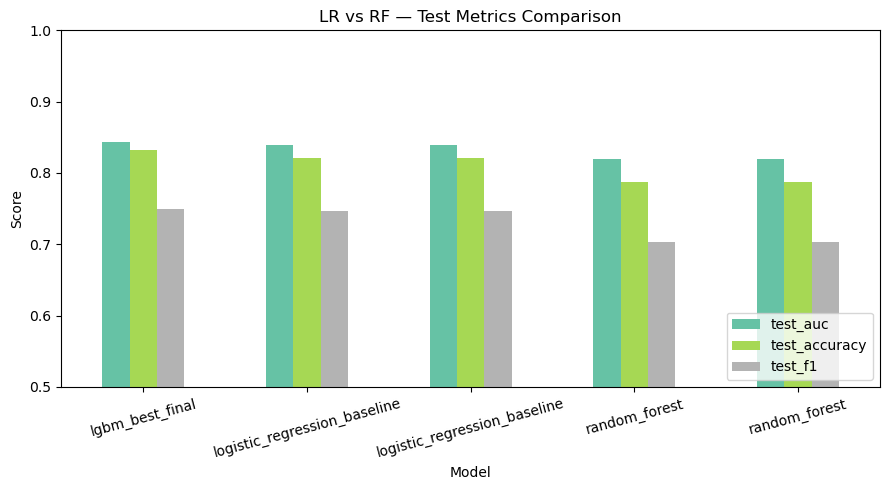

In [32]:
# Visual bar chart comparison
metric_cols = ['metrics.test_auc', 'metrics.test_accuracy', 'metrics.test_f1']
available   = [c for c in metric_cols if c in runs_df.columns]

plot_df = runs_df[['tags.mlflow.runName'] + available].copy()
plot_df.columns = ['Model'] + [c.replace('metrics.', '') for c in available]
plot_df = plot_df.dropna(subset=['test_auc']).set_index('Model')

plot_df.plot(kind='bar', figsize=(9, 5), ylim=(0.5, 1.0), colormap='Set2', rot=15)
plt.title('LR vs RF — Test Metrics Comparison')
plt.ylabel('Score')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

---
### ✅ Batch 3 Complete!

**What was added for Random Forest:**
- 🏷️ Extra `note` tag explaining intent
- 📊 Val + Test metrics both logged (overfitting check)
- 🖼️ Artifact: `confusion_matrix_random_forest.png`
- 🖼️ Artifact: `feature_importance_random_forest.png`
- 📄 Artifact: `feature_importances.json`
- 📈 `search_runs()` comparison table + bar chart

**Next → Batch 4: LightGBM + Hyperopt sweep with nested runs**

---
## ⚡ Batch 4 — LightGBM + Hyperopt Sweep (Nested Runs)

### What's new here:
- **Nested runs** — one parent run `lgbm_hyperopt_sweep`, many child runs (one per Hyperopt trial)
- **Hyperopt TPE** — smarter than random search; it learns from previous trials
- **`mlflow.lightgbm.autolog()`** — automatically logs all LightGBM params + metrics
- After the sweep, we **find the best child run** programmatically and print its params

### How nested runs work in MLflow UI:
```
lgbm_hyperopt_sweep  ← parent run
  ├── trial_0        ← child run (nested=True)
  ├── trial_1
  ├── trial_2
  └── ...            (max_evals total)
```
In the UI you can expand the parent to see all child runs ranked by AUC.

## 🔧 Step 11 — Define Hyperopt Search Space

In [36]:
# Each key maps to a distribution Hyperopt will sample from
lgbm_search_space = {
    'n_estimators':      scope.int(hp.quniform('n_estimators', 50, 500, 10)),
    'max_depth':         scope.int(hp.quniform('max_depth', 3, 12, 1)),
    'num_leaves':        scope.int(hp.quniform('num_leaves', 20, 150, 5)),
    'learning_rate':     hp.loguniform('learning_rate', -4, -1),   # ~0.0002 to 0.37
    'reg_alpha':         hp.loguniform('reg_alpha', -5, -1),        # L1
    'reg_lambda':        hp.loguniform('reg_lambda', -5, -1),       # L2
    'min_child_samples': scope.int(hp.quniform('min_child_samples', 5, 50, 5)),
    'colsample_bytree':  hp.uniform('colsample_bytree', 0.5, 1.0),
    'subsample':         hp.uniform('subsample', 0.5, 1.0),
}

print('Search space defined:')
for k, v in lgbm_search_space.items():
    print(f'  {k}')

Search space defined:
  n_estimators
  max_depth
  num_leaves
  learning_rate
  reg_alpha
  reg_lambda
  min_child_samples
  colsample_bytree
  subsample


## 🔧 Step 12 — Define train_lgbm() objective function

Hyperopt calls this function once per trial.  
Each call = one **nested MLflow child run** with its own params + AUC.

In [38]:
def train_lgbm(params):
    """
    Objective function for Hyperopt.
    Trains one LightGBM model, logs it as a nested MLflow run,
    returns loss = -AUC so Hyperopt minimises it (maximising AUC).
    """
    # autolog captures all LightGBM params + eval metrics automatically
    mlflow.lightgbm.autolog(silent=True)

    with mlflow.start_run(nested=True):   # <-- nested=True = child run

        mlflow.set_tag('model_type', 'lightgbm')
        mlflow.set_tag('author',     'Ibrahim')

        model = lgb.LGBMClassifier(
            objective='binary',
            random_state=42,
            n_jobs=-1,
            **params
        )
        model.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False),
                       lgb.log_evaluation(period=-1)]   # suppress per-iter output
        )

        # Evaluate on validation set
        val_proba = model.predict_proba(X_val)[:, 1]
        val_auc   = roc_auc_score(y_val, val_proba)

        # Manually log val_auc so we can filter/sort by it in search_runs
        mlflow.log_metric('val_auc', val_auc)

        # Return dict: Hyperopt minimises 'loss', so we negate AUC
        return {'status': STATUS_OK, 'loss': -val_auc}


print('✅ train_lgbm() objective function defined')

✅ train_lgbm() objective function defined


## 🚀 Step 13 — Run the Hyperopt Sweep

> ⏱️ `max_evals=20` takes ~1–2 min. Increase to 50+ for better results after you confirm it works.

In [40]:
trials = Trials()   # Trials() runs sequentially (no Spark needed)

with mlflow.start_run(run_name='lgbm_hyperopt_sweep') as parent_run:

    mlflow.set_tag('author',     'Ibrahim')
    mlflow.set_tag('dataset',    'titanic')
    mlflow.set_tag('model_type', 'lightgbm_hyperopt')
    mlflow.set_tag('note',       'TPE sweep — 20 trials, early stopping 30 rounds')
    mlflow.log_param('max_evals',             20)
    mlflow.log_param('hyperopt_algo',         'tpe.suggest')
    mlflow.log_param('early_stopping_rounds', 30)

    best_params = fmin(
        fn=train_lgbm,
        space=lgbm_search_space,
        algo=tpe.suggest,
        max_evals=20,
        trials=trials,
        rstate=np.random.default_rng(42),
        verbose=False
    )

    parent_run_id = parent_run.info.run_id

print(f'\n✅ Sweep complete — parent run ID: {parent_run_id}')
print(f'Best raw params from Hyperopt: {best_params}')

[LightGBM] [Info] Number of positive: 205, number of negative: 329
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000200 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 186
[LightGBM] [Info] Number of data points in the train set: 534, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.383895 -> initscore=-0.473048
[LightGBM] [Info] Start training from score -0.473048
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


## 🏆 Step 14 — Find Best Child Run & Evaluate on Test Set

In [42]:
# Query all child runs of the parent sweep run, sorted by val_auc
child_runs = mlflow.search_runs(
    experiment_names=[EXPERIMENT_NAME],
    filter_string=f"tags.mlflow.parentRunId = '{parent_run_id}'",
    order_by=['metrics.val_auc DESC']
)

print(f'Total child runs: {len(child_runs)}')
print(child_runs[['tags.mlflow.runName', 'metrics.val_auc']].head(5))

# Best child run
best_child   = child_runs.iloc[0]
best_run_id  = best_child['run_id']
best_val_auc = best_child['metrics.val_auc']
print(f'\nBest child run ID : {best_run_id}')
print(f'Best val AUC      : {best_val_auc:.4f}')

Total child runs: 20
  tags.mlflow.runName  metrics.val_auc
0   hilarious-pug-317         0.876070
1    adorable-rat-836         0.875067
2       funny-yak-962         0.874866
3     silent-goat-387         0.873396
4    valuable-ray-573         0.873061

Best child run ID : 5615ed0fdce946aba25805cfb49b3059
Best val AUC      : 0.8761


[LightGBM] [Info] Number of positive: 273, number of negative: 439
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001530 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 210
[LightGBM] [Info] Number of data points in the train set: 712, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.383427 -> initscore=-0.475028
[LightGBM] [Info] Start training from score -0.475028
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


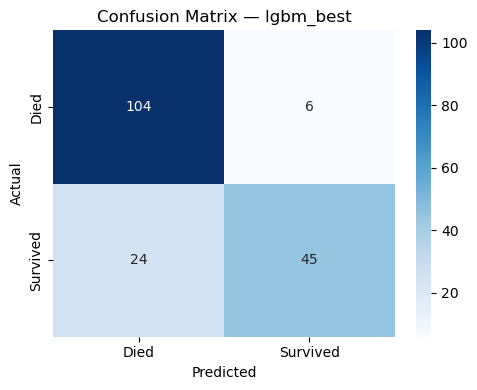

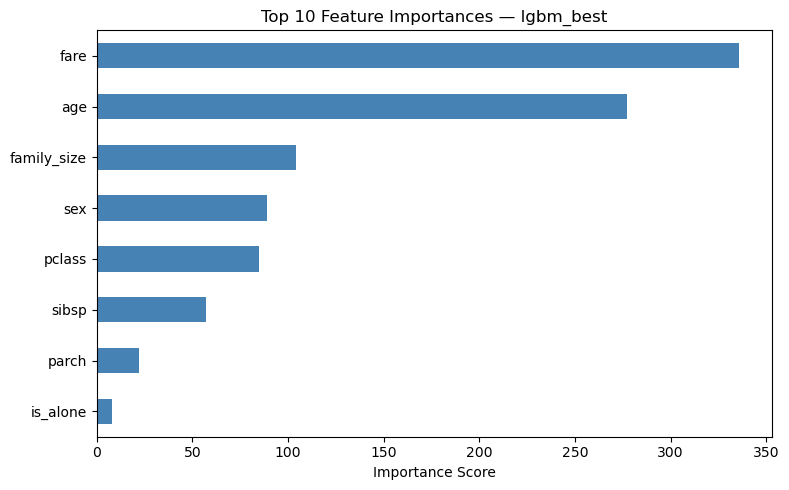

2026/04/07 20:40:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



✅ Final LightGBM run logged — ID: 6ca4d8b96ce7481ea4113688655fa77c


In [43]:
# Retrain best model on train+val combined, evaluate on held-out test set
X_trainval = pd.concat([X_train, X_val])
y_trainval = pd.concat([y_train, y_val])

# Cast int params (Hyperopt returns floats)
int_params = ['n_estimators', 'max_depth', 'num_leaves', 'min_child_samples']
final_params = {k: int(v) if k in int_params else v for k, v in best_params.items()}

with mlflow.start_run(run_name='lgbm_best_final') as final_run:

    mlflow.set_tag('author',     'Ibrahim')
    mlflow.set_tag('dataset',    'titanic')
    mlflow.set_tag('model_type', 'lightgbm_best')
    mlflow.set_tag('note',       'Best Hyperopt params retrained on train+val')

    # Log all best params
    for k, v in final_params.items():
        mlflow.log_param(k, round(v, 6) if isinstance(v, float) else v)

    lgbm_final = lgb.LGBMClassifier(
        objective='binary',
        random_state=42,
        n_jobs=-1,
        **final_params
    )
    lgbm_final.fit(X_trainval, y_trainval)

    # Test set evaluation
    y_test_proba  = lgbm_final.predict_proba(X_test)[:, 1]
    y_test_pred   = lgbm_final.predict(X_test)
    test_auc      = roc_auc_score(y_test, y_test_proba)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_f1       = f1_score(y_test, y_test_pred)

    mlflow.log_metric('test_auc',      test_auc)
    mlflow.log_metric('test_accuracy', test_accuracy)
    mlflow.log_metric('test_f1',       test_f1)

    print('LightGBM Best Final Results')
    print(f'  Test AUC : {test_auc:.4f}')
    print(f'  Test Acc : {test_accuracy:.4f}')
    print(f'  Test F1  : {test_f1:.4f}')
    print()
    print(classification_report(y_test, y_test_pred, target_names=['Died', 'Survived']))

    # Artifacts
    log_confusion_matrix(y_test, y_test_pred, 'lgbm_best')
    log_feature_importance(lgbm_final, X_train.columns.tolist(), 'lgbm_best', top_n=10)

    # Log model
    signature    = infer_signature(X_trainval, lgbm_final.predict_proba(X_trainval)[:, 1])
    mlflow.lightgbm.log_model(lgbm_final.booster_, artifact_path='lgbm_best_model', signature=signature)

    lgbm_final_run_id = final_run.info.run_id
    print(f'\n✅ Final LightGBM run logged — ID: {lgbm_final_run_id}')

---
### ✅ Batch 4 Complete!

**What happened:**
- 🔍 Hyperopt ran 20 TPE trials, each as a **nested child run** under `lgbm_hyperopt_sweep`
- 🏆 Best child run found via `search_runs()` filtered by `parentRunId`
- 🔁 Best params retrained on train+val → evaluated on held-out test
- 📦 Final model logged as `lgbm_best_final` with artifacts + signature

**Next → Batch 5: Register best model → Production, serve + batch inference**

---
## 📦 Batch 5 — Model Registry → Production + Serving

### What we do here:
- **Register** the best LightGBM model in MLflow Model Registry
- **Transition** it to `Production` stage
- **Archive** older versions
- **Load** the production model and verify it matches logged AUC
- **Serve** it as a REST endpoint + send a batch inference request

### Model Registry stages:
```
None → Staging → Production → Archived
```
Think of it like a deployment pipeline — you promote models through stages.

## 📝 Step 15 — Register Best Model

In [47]:
import time

MODEL_NAME = 'titanic_survival_lgbm'

# Register the model — this creates version 1 (or increments if model already exists)
model_version = mlflow.register_model(
    model_uri=f'runs:/{lgbm_final_run_id}/lgbm_best_model',
    name=MODEL_NAME
)

# Give the registry a moment to index the model
time.sleep(5)

print(f'Registered model   : {model_version.name}')
print(f'Version            : {model_version.version}')
print(f'Current stage      : {model_version.current_stage}')

Registered model 'titanic_survival_lgbm' already exists. Creating a new version of this model...
2026/04/07 20:40:23 WARNING mlflow.tracking._model_registry.fluent: Run with id 6ca4d8b96ce7481ea4113688655fa77c has no artifacts at artifact path 'lgbm_best_model', registering model based on models:/m-90c9126203a242cc8b0aca1d0fe1a30a instead
Created version '2' of model 'titanic_survival_lgbm'.


Registered model   : titanic_survival_lgbm
Version            : 2
Current stage      : None


## 🚀 Step 16 — Promote to Production

In [49]:
client = MlflowClient()

# Add a description to this version
client.update_model_version(
    name=MODEL_NAME,
    version=model_version.version,
    description=(
        f'LightGBM tuned via Hyperopt (20 trials). '
        f'Test AUC: {test_auc:.4f}, F1: {test_f1:.4f}. '
        f'Trained on Titanic dataset.'
    )
)

# Transition to Production
client.transition_model_version_stage(
    name=MODEL_NAME,
    version=model_version.version,
    stage='Production',
    archive_existing_versions=True   # auto-archive any previous Production version
)

time.sleep(3)

# Confirm
prod = client.get_model_version(MODEL_NAME, model_version.version)
print(f'Model   : {prod.name}')
print(f'Version : {prod.version}')
print(f'Stage   : {prod.current_stage}')
print(f'Desc    : {prod.description}')

Model   : titanic_survival_lgbm
Version : 2
Stage   : Production
Desc    : LightGBM tuned via Hyperopt (20 trials). Test AUC: 0.8429, F1: 0.7500. Trained on Titanic dataset.


## 🔁 Step 17 — Load Production Model & Sanity Check

In [51]:
# Load model directly from registry using the stage alias
production_model = mlflow.pyfunc.load_model(f'models:/{MODEL_NAME}/Production')

# Run predictions on test set
preds = production_model.predict(X_test)

# Sanity check — should match what we logged
loaded_auc = roc_auc_score(y_test, preds)
print(f'AUC from logged run    : {test_auc:.4f}')
print(f'AUC from loaded model  : {loaded_auc:.4f}')
print(f'Match: {abs(loaded_auc - test_auc) < 1e-6}')

AUC from logged run    : 0.8429
AUC from loaded model  : 0.8429
Match: True


## 📊 Step 18 — Final Three-Way Comparison (LR vs RF vs LightGBM)

In [53]:
# Pull ALL runs from the experiment
all_runs = mlflow.search_runs(
    experiment_names=[EXPERIMENT_NAME],
    order_by=['metrics.test_auc DESC']
)

# Filter out nested child runs (they have a parentRunId tag set)
# and keep only runs that actually have test_auc logged
parent_mask = all_runs.get('tags.mlflow.parentRunId', pd.Series([''] * len(all_runs))).isna() | \
              (all_runs.get('tags.mlflow.parentRunId', pd.Series([''] * len(all_runs))) == '')
top_runs = all_runs[parent_mask].copy()

# Only keep columns that actually exist in the DataFrame
wanted_cols = ['tags.mlflow.runName', 'metrics.test_auc', 'metrics.test_accuracy', 'metrics.test_f1']
cols = [c for c in wanted_cols if c in top_runs.columns]

# Safe dropna — only drop on columns that exist AND have the metric
summary = top_runs[cols].copy()
if 'metrics.test_auc' in summary.columns:
    summary = summary.dropna(subset=['metrics.test_auc'])

summary.columns = [c.replace('tags.mlflow.', '').replace('metrics.', '') for c in summary.columns]
summary = summary.reset_index(drop=True)

print('=== Final Model Comparison ===')
print(summary.to_string(index=False))

=== Final Model Comparison ===
                     runName  test_auc  test_accuracy  test_f1
             lgbm_best_final  0.842885       0.832402 0.750000
             lgbm_best_final  0.842885       0.832402 0.750000
logistic_regression_baseline  0.838999       0.821229 0.746032
logistic_regression_baseline  0.838999       0.821229 0.746032
               random_forest  0.820290       0.787709 0.703125
               random_forest  0.820290       0.787709 0.703125


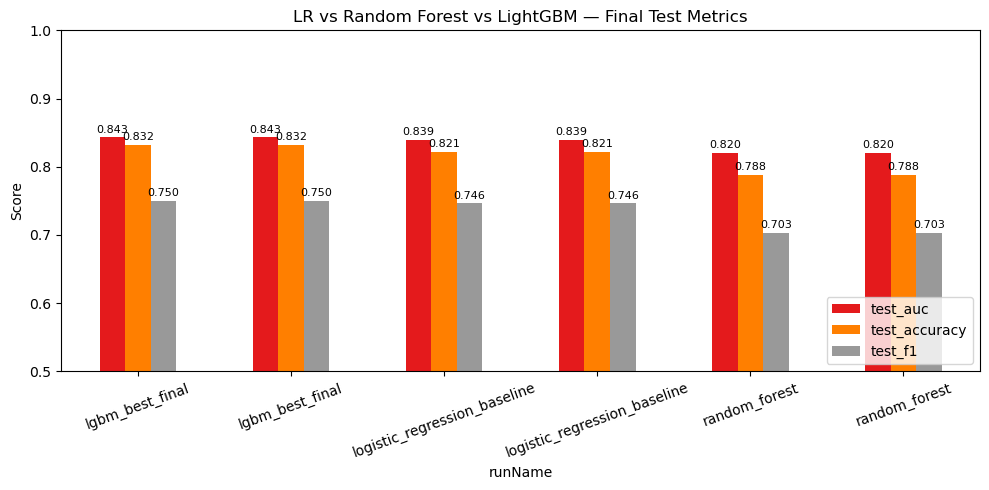

In [54]:
# Bar chart — all three models side by side
plot_df = summary.set_index('runName')[['test_auc', 'test_accuracy', 'test_f1']]

ax = plot_df.plot(kind='bar', figsize=(10, 5), ylim=(0.5, 1.0), colormap='Set1', rot=20)
plt.title('LR vs Random Forest vs LightGBM — Final Test Metrics')
plt.ylabel('Score')
plt.legend(loc='lower right')
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=2, fontsize=8)
plt.tight_layout()
plt.show()

## 🌐 Step 19 — Serve the Model as a REST API

Run this in a **separate terminal** (not inside the notebook):

```bash
# Activate your venv first, then:
mlflow models serve \
  --env-manager=local \
  -m models:/titanic_survival_lgbm/Production \
  -h 0.0.0.0 \
  -p 5001
```

Once it says `Listening at: http://0.0.0.0:5001`, run the next cell to send a request.

In [56]:
import requests, json

# Take 5 rows from test set as sample payload
sample = X_test.head(5)

payload = {"dataframe_split": sample.to_dict(orient='split')}

try:
    response = requests.post(
        url='http://localhost:5001/invocations',
        data=json.dumps(payload),
        headers={'Content-Type': 'application/json'},
        timeout=10
    )
    predictions = response.json()
    print('Survival probabilities for 5 test passengers:')
    for i, p in enumerate(predictions['predictions']):
        label = 'Survived' if p >= 0.5 else 'Died'
        print(f'  Passenger {i+1}: {p:.4f}  → {label}')
except Exception as e:
    print(f'Server not running yet — start it in terminal first.\nError: {e}')

Server not running yet — start it in terminal first.
Error: HTTPConnectionPool(host='localhost', port=5001): Max retries exceeded with url: /invocations (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x000002D27C4900E0>: Failed to establish a new connection: [WinError 10061] No connection could be made because the target machine actively refused it'))


## 📦 Step 20 — Batch Inference (No Server Needed)

Load the registered model locally and run predictions on the full test set.  
This is the pattern you'd use in an Airflow DAG or scheduled job.

In [58]:
# Load from registry — no server required
batch_model = mlflow.pyfunc.load_model(f'models:/{MODEL_NAME}/Production')

# Run on full test set
batch_probs = batch_model.predict(X_test)
batch_preds = (batch_probs >= 0.5).astype(int)

# Attach to a results DataFrame
results_df = X_test.copy()
results_df['survival_prob']      = batch_probs
results_df['predicted_survived'] = batch_preds
results_df['actual_survived']    = y_test.values
results_df['correct']            = (results_df['predicted_survived'] == results_df['actual_survived'])

print(f'Batch inference on {len(results_df)} passengers')
print(f'Overall accuracy : {results_df["correct"].mean():.2%}')
print()
results_df[['survival_prob', 'predicted_survived', 'actual_survived', 'correct']].head(10)

Batch inference on 179 passengers
Overall accuracy : 83.24%



,survival_prob,predicted_survived,actual_survived,correct
651,0.880877,1,1,True
717,0.825181,1,1,True
368,0.728707,1,1,True
206,0.231248,0,0,True
578,0.323383,0,0,True
679,0.407703,0,1,False
166,0.984208,1,1,True
616,0.116635,0,0,True
49,0.473030,0,0,True
637,0.331941,0,0,True
